In [1]:
import pandas as pd

df = pd.read_csv('../Data/PS_20174392719_1491204439457_log.csv')
df.shape

(6362620, 11)

In [2]:
X = df.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
X = pd.get_dummies(X, columns=['type'], drop_first=True)
y = df['isFraud']

X.shape

(6362620, 11)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5090096, 11), (1272524, 11))

In [4]:
train_df = X_train.copy()
train_df['isFraud'] = y_train

fraud_train = train_df[train_df['isFraud'] == 1]
genuine_sample = train_df[train_df['isFraud'] == 0].sample(n=200_000, random_state=42)

train_sampled = pd.concat([fraud_train, genuine_sample])

X_train_sampled = train_sampled.drop('isFraud', axis=1)
y_train_sampled = train_sampled['isFraud']

y_train_sampled.value_counts()

isFraud
0    200000
1      6570
Name: count, dtype: int64

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sampled, y_train_sampled)

y_train_smote.value_counts()

isFraud
1    200000
0    200000
Name: count, dtype: int64

In [6]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

y_pred = model_rf.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.29      0.98      0.45      1643

    accuracy                           1.00   1272524
   macro avg       0.65      0.99      0.73   1272524
weighted avg       1.00      1.00      1.00   1272524



In [8]:
genuine_sample = train_df[train_df['isFraud'] == 0].sample(n=1_000_000, random_state=42)

train_sampled = pd.concat([fraud_train, genuine_sample])
X_train_sampled = train_sampled.drop('isFraud', axis=1)
y_train_sampled = train_sampled['isFraud']

X_train_smote, y_train_smote = smote.fit_resample(X_train_sampled, y_train_sampled)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.47      0.98      0.63      1643

    accuracy                           1.00   1272524
   macro avg       0.73      0.99      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524



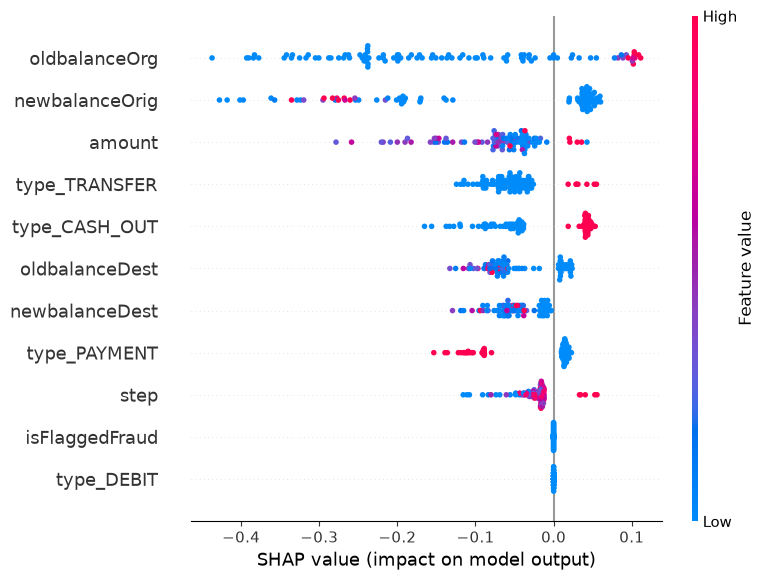

In [9]:
import shap

explainer = shap.TreeExplainer(model_rf)
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)
shap_values_fraud = shap_values[:, :, 1]

shap.summary_plot(shap_values_fraud, X_sample)

In [10]:
import joblib
joblib.dump(model_rf, '../models/fraud_model_paysim.pkl')

['../models/fraud_model_paysim.pkl']

In [11]:
model_rf.feature_names_in_

array(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype=object)